In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [3]:
df = pd.read_csv('train.csv')
df.head()
print("\nMissing Values")
print(df.isnull().sum().to_string())


Missing Values
Id                  0
MSSubClass          0
MSZoning            0
LotFrontage       259
LotArea             0
Street              0
Alley            1369
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        872
MasVnrArea          8
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           37
BsmtCond           37
BsmtExposure       38
BsmtFinType1       37
BsmtFinSF1          0
BsmtFinType2       38
BsmtFinSF2          0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF        

In [4]:


train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.info()

Train shape: (1460, 81)
Test shape: (1459, 80)
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1

In [5]:
print("Numerical columns:")
print(train.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical columns:")
print(train.select_dtypes(include="object").columns.tolist())

Numerical columns:
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Categorical columns:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'Fireplac

C:\Users\sathi\AppData\Local\Temp\ipykernel_37380\2020478813.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(train.select_dtypes(include="object").columns.tolist())


In [6]:
missing = train.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": (missing / len(train)) * 100
})

missing_df

,Missing Count,Missing %
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


In [7]:
print("SalePrice skewness:",
      train["SalePrice"].skew())

SalePrice skewness: 1.8828757597682129


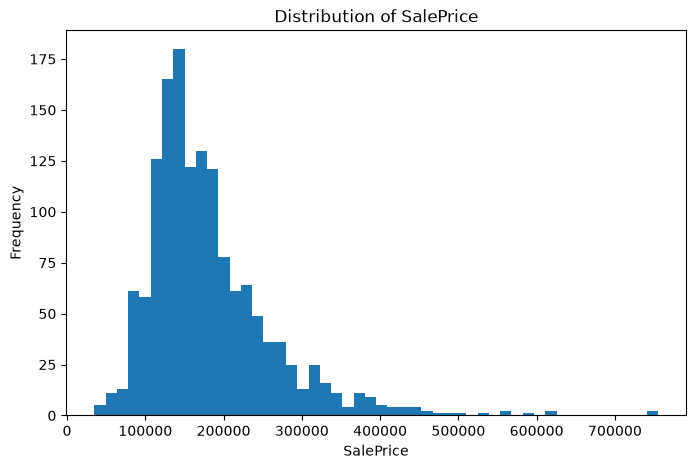

In [8]:
plt.figure(figsize=(8, 5))

plt.hist(train["SalePrice"], bins=50)

plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.title("Distribution of SalePrice")

plt.show()

In [9]:
log_price = np.log1p(train["SalePrice"])

print("Original skewness:",
      train["SalePrice"].skew())

print("Log-transformed skewness:",
      log_price.skew())

Original skewness: 1.8828757597682129
Log-transformed skewness: 0.12134661989685333


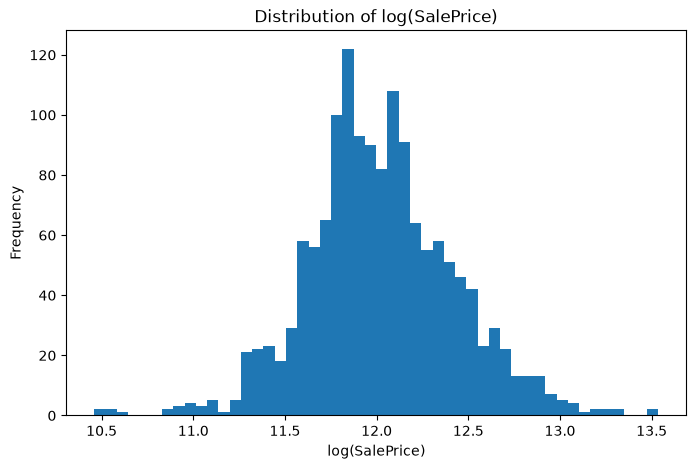

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(log_price, bins=50)

plt.xlabel("log(SalePrice)")
plt.ylabel("Frequency")
plt.title("Distribution of log(SalePrice)")

plt.show()

In [11]:
numeric_cols = train.select_dtypes(include=np.number).columns

skewness = train[numeric_cols].skew().sort_values(ascending=False)

skewness

MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
LowQualFinSF      9.011341
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
EnclosedPorch     3.089872
MasVnrArea        2.669084
OpenPorchSF       2.364342
LotFrontage       2.163569
SalePrice         1.882876
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
TotalBsmtSF       1.524255
MSSubClass        1.407657
1stFlrSF          1.376757
GrLivArea         1.366560
BsmtUnfSF         0.920268
2ndFlrSF          0.813030
OverallCond       0.693067
TotRmsAbvGrd      0.676341
HalfBath          0.675897
Fireplaces        0.649565
BsmtFullBath      0.596067
OverallQual       0.216944
MoSold            0.212053
BedroomAbvGr      0.211790
GarageArea        0.179981
YrSold            0.096269
FullBath          0.036562
Id                0.000000
GarageCars       -0.342549
YearRemodAdd     -0.503562
YearBuilt        -0.613461
G

In [12]:
skewed_features = skewness[abs(skewness) > 0.75]

print(skewed_features)

MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
LowQualFinSF      9.011341
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
EnclosedPorch     3.089872
MasVnrArea        2.669084
OpenPorchSF       2.364342
LotFrontage       2.163569
SalePrice         1.882876
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
TotalBsmtSF       1.524255
MSSubClass        1.407657
1stFlrSF          1.376757
GrLivArea         1.366560
BsmtUnfSF         0.920268
2ndFlrSF          0.813030
dtype: float64


In [13]:
numeric_data = train.select_dtypes(
    include=np.number
)

correlation = numeric_data.corr()

saleprice_corr = correlation["SalePrice"].sort_values(
    ascending=False
)

print(saleprice_corr)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

In [14]:
top_features = (
    saleprice_corr.abs()
    .sort_values(ascending=False)
    .head(11)
    .index
)

print(top_features)

Index(['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
       'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt',
       'YearRemodAdd'],
      dtype='str')


In [15]:
numeric_cols = train.select_dtypes(
    include=np.number
).columns

outlier_summary = []

for col in numeric_cols:
    
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    count = (
        (train[col] < lower) |
        (train[col] > upper)
    ).sum()
    
    outlier_summary.append(
        [col, count, count / len(train) * 100]
    )

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["Feature", "Outlier Count", "Outlier %"]
)

outlier_df.sort_values(
    "Outlier Count",
    ascending=False
)

,Feature,Outlier Count,Outlier %
30,EnclosedPorch,208,14.246575
10,BsmtFinSF2,167,11.438356
5,OverallCond,125,8.561644
32,ScreenPorch,116,7.945205
1,MSSubClass,103,7.054795
8,MasVnrArea,96,6.575342
2,LotFrontage,88,6.027397
18,BsmtHalfBath,82,5.616438
29,OpenPorchSF,77,5.273973
3,LotArea,69,4.726027


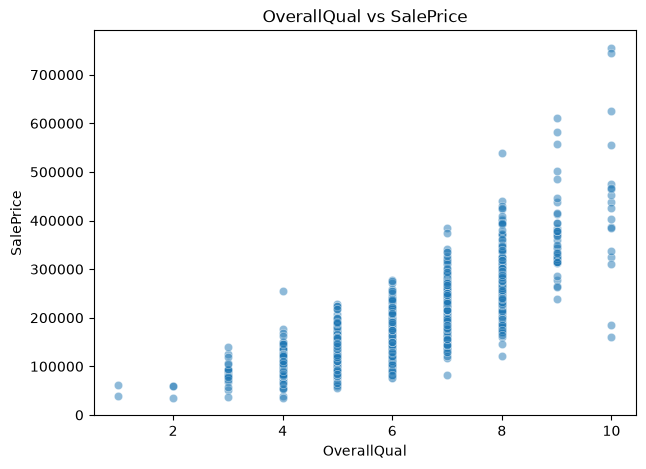

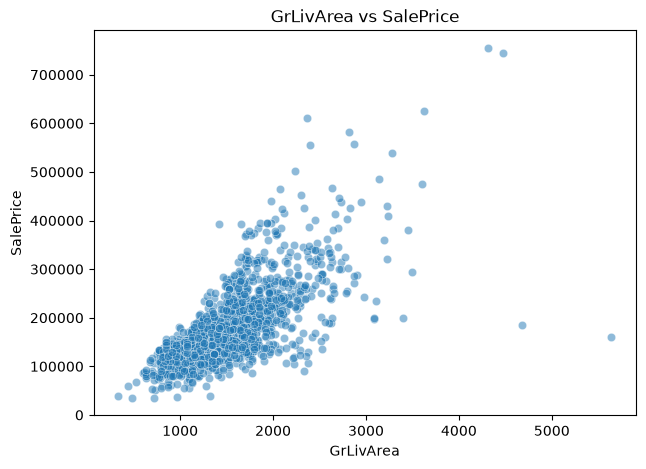

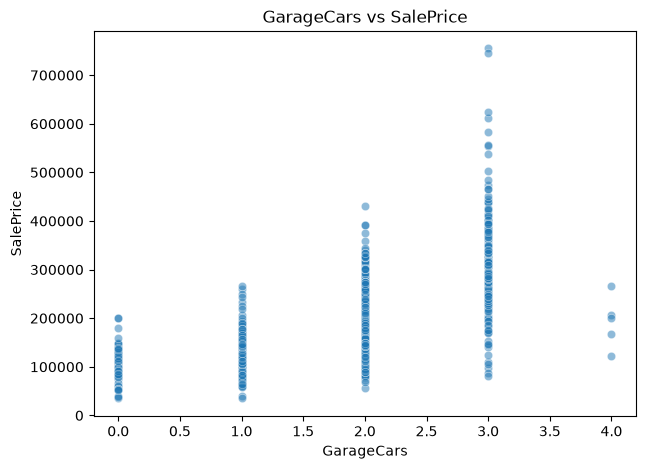

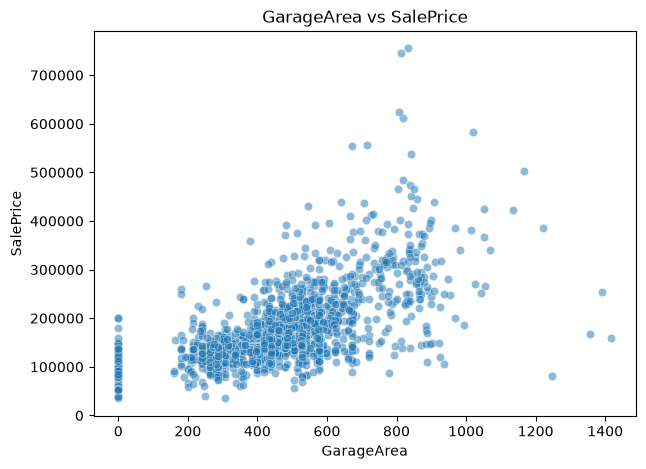

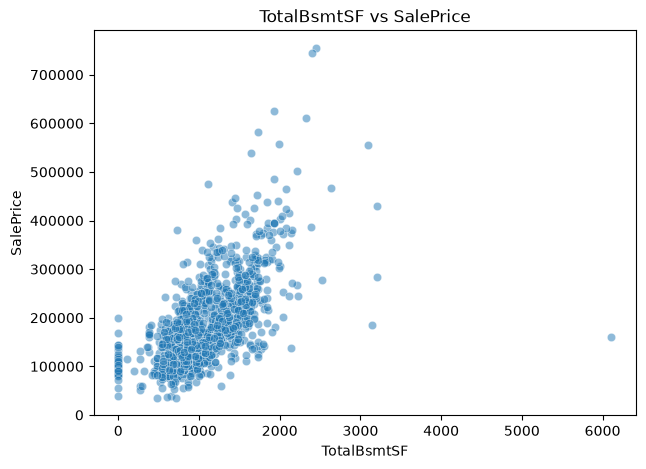

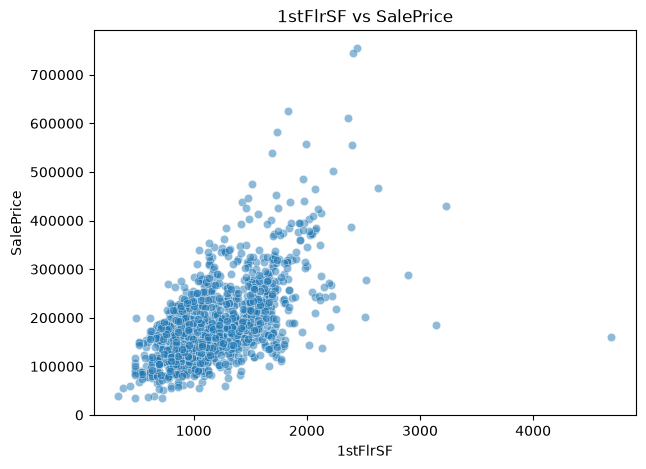

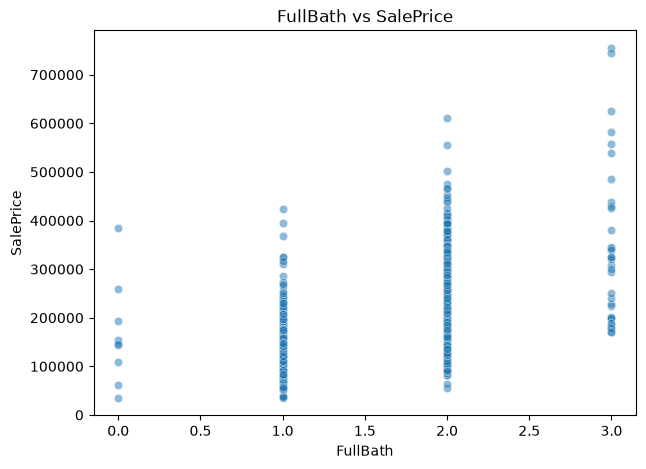

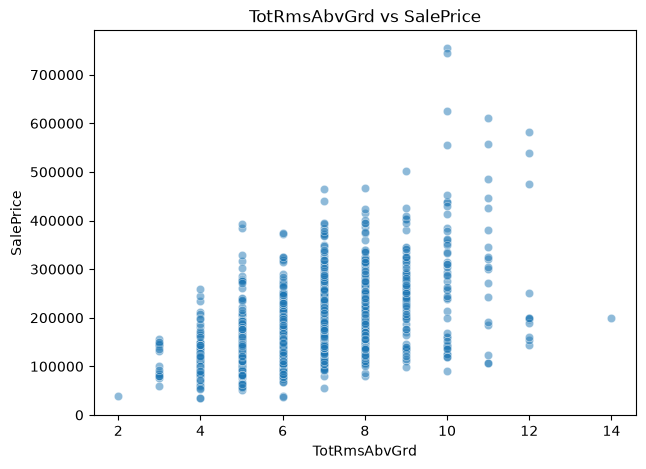

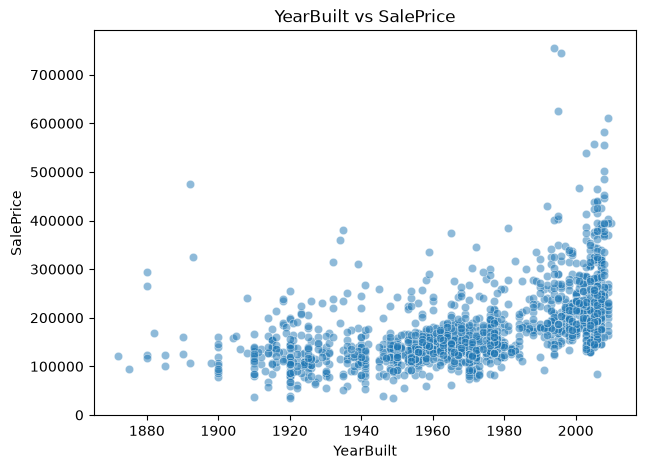

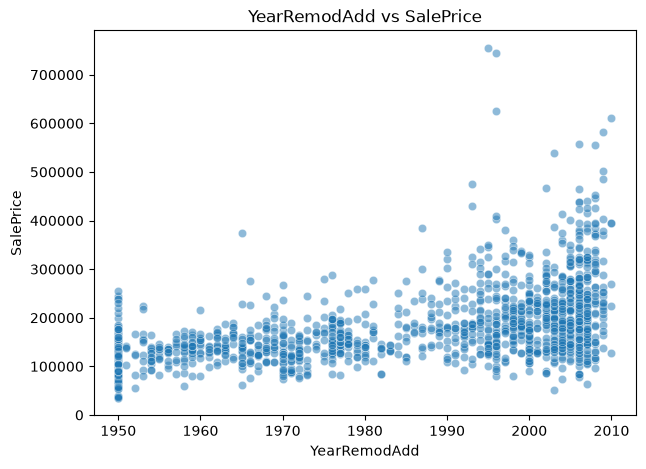

In [16]:
features = [
    'OverallQual',
    'GrLivArea',
    'GarageCars',
    'GarageArea',
    'TotalBsmtSF',
    '1stFlrSF',
    'FullBath',
    'TotRmsAbvGrd',
    'YearBuilt',
    'YearRemodAdd'
]

for feature in features:

    plt.figure(figsize=(7, 5))

    sns.scatterplot(
        data=train,
        x=feature,
        y="SalePrice",
        alpha=0.5
    )

    plt.xlabel(feature)
    plt.ylabel("SalePrice")
    plt.title(f"{feature} vs SalePrice")

    plt.show()

In [17]:
numeric_cols = train.select_dtypes(include=np.number).columns

num_corr = train[numeric_cols].corr()

In [18]:
corr_matrix = num_corr.abs()

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):

        corr_value = corr_matrix.iloc[i, j]

        if corr_value >= 0.80:
            high_corr_pairs.append([
                corr_matrix.index[i],
                corr_matrix.columns[j],
                corr_value
            ])

high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=["Feature 1", "Feature 2", "Correlation"]
).sort_values("Correlation", ascending=False)

high_corr_df

,Feature 1,Feature 2,Correlation
3,GarageCars,GarageArea,0.882475
0,YearBuilt,GarageYrBlt,0.825667
2,GrLivArea,TotRmsAbvGrd,0.825489
1,TotalBsmtSF,1stFlrSF,0.819530


In [19]:
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

In [20]:
def cramers_v(x, y):

    table = pd.crosstab(x, y)

    chi2 = chi2_contingency(table)[0]

    n = table.sum().sum()

    phi2 = chi2 / n

    r, k = table.shape

    phi2corr = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )

    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    return np.sqrt(
        phi2corr / min(kcorr - 1, rcorr - 1)
    )

In [21]:
categorical_cols = train.select_dtypes(
    include="object"
).columns

cat_assoc = []

for i in range(len(categorical_cols)):
    for j in range(i + 1, len(categorical_cols)):

        col1 = categorical_cols[i]
        col2 = categorical_cols[j]

        score = cramers_v(
            train[col1].fillna("Missing"),
            train[col2].fillna("Missing")
        )

        cat_assoc.append([
            col1,
            col2,
            score
        ])

cat_assoc_df = pd.DataFrame(
    cat_assoc,
    columns=["Feature 1", "Feature 2", "Cramers V"]
).sort_values(
    "Cramers V",
    ascending=False
)

cat_assoc_df

C:\Users\sathi\AppData\Local\Temp\ipykernel_37380\139052708.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train.select_dtypes(


,Feature 1,Feature 2,Cramers V
525,Exterior1st,Exterior2nd,0.758884
875,GarageQual,GarageCond,0.704239
858,GarageType,GarageFinish,0.684925
7,MSZoning,Neighborhood,0.640629
867,GarageFinish,GarageQual,0.588926
...,...,...,...
878,GarageQual,Fence,0.000000
207,Utilities,RoofStyle,0.000000
208,Utilities,RoofMatl,0.000000
13,MSZoning,RoofMatl,0.000000


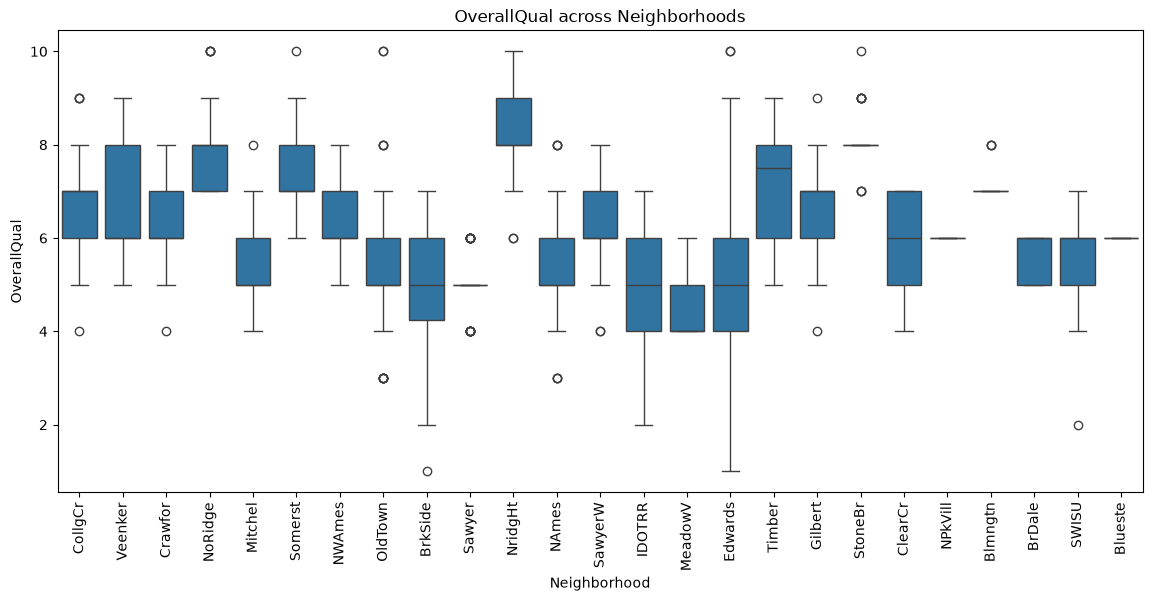

In [22]:
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=train,
    x="Neighborhood",
    y="OverallQual"
)

plt.xticks(rotation=90)
plt.title("OverallQual across Neighborhoods")

plt.show()

Preprocessing phase : 


In [23]:
X = train.drop(columns=["SalePrice", "Id"]).copy()
y = train["SalePrice"].copy()

test_X = test.drop(columns=["Id"]).copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Test X shape:", test_X.shape)

X shape: (1460, 79)
y shape: (1460,)
Test X shape: (1459, 79)


In [24]:
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(include="object").columns.tolist()

print("Number of numerical features:", len(numeric_cols))
print("Number of categorical features:", len(categorical_cols))

print("\nNumerical columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Number of numerical features: 36
Number of categorical features: 43

Numerical columns:
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']

Categorical columns:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'E

C:\Users\sathi\AppData\Local\Temp\ipykernel_37380\989642598.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns.tolist()


Define categorical columns where missing means "absence"

From our EDA, these missing values represent the absence of that house feature, so we should explicitly encode them as "None".


In [25]:
none_cols = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "MasVnrType",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2"
]

In [26]:
for col in none_cols:
    X[col] = X[col].fillna("None")
    test_X[col] = test_X[col].fillna("None")

In [27]:
remaining_train_missing = X.isnull().sum()
remaining_train_missing = remaining_train_missing[
    remaining_train_missing > 0
].sort_values(ascending=False)

print("Remaining missing values in train:")
print(remaining_train_missing)

Remaining missing values in train:
LotFrontage    259
GarageYrBlt     81
MasVnrArea       8
Electrical       1
dtype: int64


In [28]:
remaining_test_missing = test_X.isnull().sum()
remaining_test_missing = remaining_test_missing[
    remaining_test_missing > 0
].sort_values(ascending=False)

print("\nRemaining missing values in test:")
print(remaining_test_missing)


Remaining missing values in test:
LotFrontage     227
GarageYrBlt      78
MasVnrArea       15
MSZoning          4
BsmtFullBath      2
Utilities         2
BsmtHalfBath      2
Functional        2
Exterior1st       1
Exterior2nd       1
TotalBsmtSF       1
BsmtUnfSF         1
BsmtFinSF2        1
BsmtFinSF1        1
KitchenQual       1
GarageCars        1
GarageArea        1
SaleType          1
dtype: int64


In [30]:

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

In [31]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [32]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_cols
        ),
        (
            "cat",
            categorical_transformer,
            categorical_cols
        )
    ]
)

In [33]:
X_processed = preprocessor.fit_transform(X)

print("Processed shape:", X_processed.shape)

Processed shape: (1460, 302)


In [34]:
print("Any missing values after preprocessing:",
      np.isnan(X_processed.toarray()).any()
      if hasattr(X_processed, "toarray")
      else np.isnan(X_processed).any())

Any missing values after preprocessing: False
